# Objectif du jour
*Maîtriser les techniques avancées de Pandas : merge, pivot tables, chaînes de méthodes et manipulation de données complexes.*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset 1 : Clients
clients = pd.DataFrame({
    "client_id": [1, 2, 3, 4, 5],
    "nom": ["Alice", "Bob", "Carol", "David", "Eve"],
    "ville": ["Douala", "Yaoundé", "Bafoussam", "Douala", "Garoua"],
    "age": [28, 35, 24, 42, 31]
})

# Dataset 2 : Commandes
commandes = pd.DataFrame({
    "commande_id": [101, 102, 103, 104, 105, 106],
    "client_id": [1, 2, 1, 3, 2, 6],  # client_id 6 n'existe pas dans clients !
    "produit": ["Laptop", "Téléphone", "Tablette", "Laptop", "Accessoire", "Téléphone"],
    "montant": [850000, 120000, 350000, 920000, 45000, 180000]
})

print("=== CLIENTS ===")
print(clients)
print("\n=== COMMANDES ===")
print(commandes)

=== CLIENTS ===
   client_id    nom      ville  age
0          1  Alice     Douala   28
1          2    Bob    Yaoundé   35
2          3  Carol  Bafoussam   24
3          4  David     Douala   42
4          5    Eve     Garoua   31

=== COMMANDES ===
   commande_id  client_id     produit  montant
0          101          1      Laptop   850000
1          102          2   Téléphone   120000
2          103          1    Tablette   350000
3          104          3      Laptop   920000
4          105          2  Accessoire    45000
5          106          6   Téléphone   180000


### Note : le client_id 6 dans les commandes n'existe pas dans clients — c'est volontaire pour te montrer comment les différents types de jointures gèrent ce cas !

*Les 4 types de jointures :*

In [3]:
# INNER JOIN - garde uniquement les correspondances des deux côtés
inner = pd.merge(clients, commandes, on="client_id", how="inner")
print("=== INNER JOIN ===")
print(inner)
print(f"Lignes : {len(inner)}")

# LEFT JOIN - garde tout le côté gauche (clients)
left = pd.merge(clients, commandes, on="client_id", how="left")
print("\n=== LEFT JOIN ===")
print(left)
print(f"Lignes : {len(left)}")

# RIGHT JOIN - garde tout le côté droit (commandes)
right = pd.merge(clients, commandes, on="client_id", how="right")
print("\n=== RIGHT JOIN ===")
print(right)
print(f"Lignes : {len(right)}")

# OUTER JOIN - garde tout des deux côtés
outer = pd.merge(clients, commandes, on="client_id", how="outer")
print("\n=== OUTER JOIN ===")
print(outer)
print(f"Lignes : {len(outer)}")

=== INNER JOIN ===
   client_id    nom      ville  age  commande_id     produit  montant
0          1  Alice     Douala   28          101      Laptop   850000
1          1  Alice     Douala   28          103    Tablette   350000
2          2    Bob    Yaoundé   35          102   Téléphone   120000
3          2    Bob    Yaoundé   35          105  Accessoire    45000
4          3  Carol  Bafoussam   24          104      Laptop   920000
Lignes : 5

=== LEFT JOIN ===
   client_id    nom      ville  age  commande_id     produit   montant
0          1  Alice     Douala   28        101.0      Laptop  850000.0
1          1  Alice     Douala   28        103.0    Tablette  350000.0
2          2    Bob    Yaoundé   35        102.0   Téléphone  120000.0
3          2    Bob    Yaoundé   35        105.0  Accessoire   45000.0
4          3  Carol  Bafoussam   24        104.0      Laptop  920000.0
5          4  David     Douala   42          NaN         NaN       NaN
6          5    Eve     Garoua   3

# Les jointures en image :
*INNER → uniquement ce qui est en commun ∩
LEFT → tout le tableau gauche + correspondances droite
RIGHT → tout le tableau droit + correspondances gauche
OUTER → tout des deux tableaux ∪*

 # Merge avancé

In [4]:
# Dataset 3 : Produits
produits = pd.DataFrame({
    "produit": ["Laptop", "Téléphone", "Tablette", "Accessoire"],
    "categorie": ["Informatique", "Mobile", "Mobile", "Accessoire"],
    "prix_moyen": [850000, 120000, 350000, 45000],
    "stock": [15, 50, 30, 100]
})

# Joindre les 3 tables en chaîne
df_complet = pd.merge(clients, commandes, on="client_id", how="inner")
df_complet = pd.merge(df_complet, produits, on="produit", how="left")

print("=== DATASET COMPLET ===")
print(df_complet)
print(f"\nColonnes : {df_complet.columns.tolist()}")

# Détecter les doublons de colonnes
print("\n=== INFOS ===")
df_complet.info()

=== DATASET COMPLET ===
   client_id    nom      ville  age  commande_id     produit  montant  \
0          1  Alice     Douala   28          101      Laptop   850000   
1          1  Alice     Douala   28          103    Tablette   350000   
2          2    Bob    Yaoundé   35          102   Téléphone   120000   
3          2    Bob    Yaoundé   35          105  Accessoire    45000   
4          3  Carol  Bafoussam   24          104      Laptop   920000   

      categorie  prix_moyen  stock  
0  Informatique      850000     15  
1        Mobile      350000     30  
2        Mobile      120000     50  
3    Accessoire       45000    100  
4  Informatique      850000     15  

Colonnes : ['client_id', 'nom', 'ville', 'age', 'commande_id', 'produit', 'montant', 'categorie', 'prix_moyen', 'stock']

=== INFOS ===
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cli

### Pivot table basique :

In [6]:
# Créer un dataset de ventes plus complet
np.random.seed(42)
df_ventes = pd.DataFrame({
    "vendeur": np.random.choice(["Alice", "Bob", "Carol"], 50),
    "produit": np.random.choice(["Laptop", "Téléphone", "Tablette"], 50),
    "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam"], 50),
    "mois": np.random.choice(["Jan", "Fév", "Mar", "Avr"], 50),
    "montant": np.random.randint(50000, 500000, 50),
    "quantite": np.random.randint(1, 10, 50)
})

# Pivot table simple : montant moyen par vendeur et produit
pivot1 = df_ventes.pivot_table(
    values="montant",
    index="vendeur",
    columns="produit",
    aggfunc="mean"
).round(0)

print("=== MONTANT MOYEN PAR VENDEUR ET PRODUIT ===")
display(pivot1)

=== MONTANT MOYEN PAR VENDEUR ET PRODUIT ===


produit,Laptop,Tablette,Téléphone
vendeur,,,
Alice,220716.0,290588.0,238930.0
Bob,262813.0,275281.0,372986.0
Carol,276278.0,237386.0,252184.0


**💡 La pivot table c'est exactement le tableau croisé dynamique d'Excel — mais en Python ! Tu croises deux variables catégorielles et tu appliques 
 une agrégation sur une variable numérique. Très puissant pour l'analyse business !**

#### Pivot tables avancées :

In [7]:
# Pivot table avec plusieurs agrégations
pivot2 = df_ventes.pivot_table(
    values="montant",
    index="ville",
    columns="mois",
    aggfunc=["mean", "sum"],
    fill_value=0  # remplace les NaN par 0
).round(0)

print("=== MONTANT PAR VILLE ET MOIS ===")
display(pivot2)

# Pivot table avec margins (totaux)
pivot3 = df_ventes.pivot_table(
    values="quantite",
    index="vendeur",
    columns="produit",
    aggfunc="sum",
    margins=True,       # ajoute les totaux
    margins_name="Total"
)

print("\n=== QUANTITÉS VENDUES AVEC TOTAUX ===")
display(pivot3)

=== MONTANT PAR VILLE ET MOIS ===


mean                                    sum                    \
mois            Avr       Fév       Jan       Mar      Avr      Fév      Jan   
ville                                                                          
Bafoussam  211070.0  238167.0  324068.0  331998.0  1477491  1429002  1944411   
Douala     176264.0  271955.0  252043.0  324378.0   528792  1087821  1008173   
Yaoundé    367495.0  264283.0  240861.0  324158.0  1102486   264283   963443   

                    
mois           Mar  
ville               
Bafoussam  1991987  
Douala     1297514  
Yaoundé     648316


=== QUANTITÉS VENDUES AVEC TOTAUX ===


produit,Laptop,Tablette,Téléphone,Total
vendeur,,,,
Alice,16,22,28,66
Bob,37,7,40,84
Carol,42,36,21,99
Total,95,65,89,249


**💡 margins=True ajoute automatiquement une ligne et une colonne Total — exactement comme dans Excel ! C'est très utile pour les rapports business.
💡 fill_value=0 remplace les NaN par 0 — quand une combinaison ville/mois n'a pas de ventes, on affiche 0 plutôt qu'une valeur manquante.**

## Reshaping avec melt et stack :

In [8]:
# melt : transformer un tableau large en tableau long
# (l'inverse de pivot_table)

df_large = pd.DataFrame({
    "vendeur": ["Alice", "Bob", "Carol"],
    "Jan": [150000, 200000, 180000],
    "Fév": [220000, 190000, 250000],
    "Mar": [180000, 210000, 160000]
})

print("=== FORMAT LARGE (wide) ===")
print(df_large)

# Transformer en format long
df_long = df_large.melt(
    id_vars="vendeur",      # colonne à garder fixe
    var_name="mois",        # nom de la nouvelle colonne catégorielle
    value_name="montant"    # nom de la nouvelle colonne de valeurs
)

print("\n=== FORMAT LONG (long) ===")
print(df_long)

=== FORMAT LARGE (wide) ===
  vendeur     Jan     Fév     Mar
0   Alice  150000  220000  180000
1     Bob  200000  190000  210000
2   Carol  180000  250000  160000

=== FORMAT LONG (long) ===
  vendeur mois  montant
0   Alice  Jan   150000
1     Bob  Jan   200000
2   Carol  Jan   180000
3   Alice  Fév   220000
4     Bob  Fév   190000
5   Carol  Fév   250000
6   Alice  Mar   180000
7     Bob  Mar   210000
8   Carol  Mar   160000


**💡 Wide vs Long — deux formats fondamentaux en data science :
Format large (wide) → une colonne par variable — facile à lire pour les humains
Format long → une ligne par observation — requis par la plupart des algorithmes ML et des graphiques Seaborn !**

In [16]:
# Plusieurs colonnes catégorielles et plusieurs colonnes valeurs
df_complexe = pd.DataFrame({
    "vendeur": ["Alice", "Bob", "Carol"],
    "ville": ["Douala", "Yaoundé", "Bafoussam"],
    "Jan_montant": [150000, 200000, 180000],
    "Jan_quantite": [3, 5, 4],
    "Fév_montant": [220000, 190000, 250000],
    "Fév_quantite": [6, 4, 7]
})

print("=== FORMAT LARGE ===")
print(df_complexe)

# Plusieurs colonnes catégorielles fixées
df_long2 = df_complexe.melt(
    id_vars=["vendeur", "ville"],  # ← liste de colonnes fixes
    var_name="mois_metric",
    value_name="valeur"
)

print("\n=== FORMAT LONG ===")
print(df_long2)

=== FORMAT LARGE ===
  vendeur      ville  Jan_montant  Jan_quantite  Fév_montant  Fév_quantite
0   Alice     Douala       150000             3       220000             6
1     Bob    Yaoundé       200000             5       190000             4
2   Carol  Bafoussam       180000             4       250000             7

=== FORMAT LONG ===
   vendeur      ville   mois_metric  valeur
0    Alice     Douala   Jan_montant  150000
1      Bob    Yaoundé   Jan_montant  200000
2    Carol  Bafoussam   Jan_montant  180000
3    Alice     Douala  Jan_quantite       3
4      Bob    Yaoundé  Jan_quantite       5
5    Carol  Bafoussam  Jan_quantite       4
6    Alice     Douala   Fév_montant  220000
7      Bob    Yaoundé   Fév_montant  190000
8    Carol  Bafoussam   Fév_montant  250000
9    Alice     Douala  Fév_quantite       6
10     Bob    Yaoundé  Fév_quantite       4
11   Carol  Bafoussam  Fév_quantite       7


In [17]:
# Séparer "Jan_montant" en "Jan" et "montant"
df_long2[["mois", "metric"]] = df_long2["mois_metric"].str.split("_", expand=True)
df_long2 = df_long2.drop(columns=["mois_metric"])

print("\n=== FORMAT LONG PROPRE ===")
print(df_long2)


=== FORMAT LONG PROPRE ===
   vendeur      ville  valeur mois    metric
0    Alice     Douala  150000  Jan   montant
1      Bob    Yaoundé  200000  Jan   montant
2    Carol  Bafoussam  180000  Jan   montant
3    Alice     Douala       3  Jan  quantite
4      Bob    Yaoundé       5  Jan  quantite
5    Carol  Bafoussam       4  Jan  quantite
6    Alice     Douala  220000  Fév   montant
7      Bob    Yaoundé  190000  Fév   montant
8    Carol  Bafoussam  250000  Fév   montant
9    Alice     Douala       6  Fév  quantite
10     Bob    Yaoundé       4  Fév  quantite
11   Carol  Bafoussam       7  Fév  quantite


**💡 Résumé des outils de reshaping :
En pratique melt + str.split() est la combinaison la plus utilisée car elle est plus flexible que wide_to_long. Tu la reverras souvent !** 

## Chaînes de méthodes et apply avancé !

### Chaînes de méthodes (method chaining) :

In [20]:
# Sans chaîne de méthodes — difficile à lire
df1 = df_ventes[df_ventes["montant"] > 100000]
df2 = df1.groupby("vendeur")["montant"].sum()
df3 = df2.sort_values(ascending=False)
df4 = df3.reset_index()
print(df4)

# Avec chaîne de méthodes — propre et lisible !
resultat = (df_ventes
    .query("montant > 100000")           # filtrer
    .groupby("vendeur")["montant"]       # grouper
    .sum()                               # agréger
    .sort_values(ascending=False)        # trier
    .reset_index()                       # remettre l'index
    .rename(columns={"montant": "CA"})   # renommer
)
print("\n=== RÉSULTAT PROPRE ===")
print(resultat)

  vendeur  montant
0   Carol  5036228
1     Bob  4746697
2   Alice  3735937

=== RÉSULTAT PROPRE ===
  vendeur       CA
0   Carol  5036228
1     Bob  4746697
2   Alice  3735937


**💡 Le method chaining c'est le style d'écriture des data scientists professionnels — au lieu de créer des variables intermédiaires df1, df2, df3..., on enchaîne les opérations. C'est plus lisible et plus efficace !**

In [21]:
# Sans reset_index
sans = (df_ventes
    .query("montant > 100000")
    .groupby("vendeur")["montant"]
    .sum()
    .sort_values(ascending=False)
)
print("=== SANS reset_index ===")
print(sans)
print("Type :", type(sans))

# Avec reset_index
avec = (df_ventes
    .query("montant > 100000")
    .groupby("vendeur")["montant"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print("=== AVEC reset_index ===")
print(avec)
print("Type :", type(avec))

=== SANS reset_index ===
vendeur
Carol    5036228
Bob      4746697
Alice    3735937
Name: montant, dtype: int32
Type : <class 'pandas.Series'>
=== AVEC reset_index ===
  vendeur  montant
0   Carol  5036228
1     Bob  4746697
2   Alice  3735937
Type : <class 'pandas.DataFrame'>


**💡 Règle simple à retenir :
Tu veux afficher le résultat → pas besoin de reset_index()
Tu veux continuer à manipuler le résultat → utilise reset_index()**

## Apply avancé :

In [22]:
# Apply avec fonction lambda
df_ventes["montant_milliers"] = df_ventes["montant"].apply(lambda x: round(x/1000, 1))
print("=== MONTANT EN MILLIERS ===")
print(df_ventes[["montant", "montant_milliers"]].head())

# Apply avec fonction personnalisée
def classifier_vente(montant):
    if montant < 100000:
        return "Petite vente"
    elif montant < 300000:
        return "Vente moyenne"
    else:
        return "Grande vente"

df_ventes["categorie_vente"] = df_ventes["montant"].apply(classifier_vente)
print("\n=== CATÉGORIES DE VENTES ===")
print(df_ventes["categorie_vente"].value_counts())

# Apply sur plusieurs colonnes avec axis=1
df_ventes["performance"] = df_ventes.apply(
    lambda row: "Top" if row["montant"] > 300000 and row["quantite"] > 5 else "Normal",
    axis=1
)
print("\n=== PERFORMANCE ===")
print(df_ventes["performance"].value_counts())

=== MONTANT EN MILLIERS ===
   montant  montant_milliers
0    71959              72.0
1   186602             186.6
2   275928             275.9
3   431245             431.2
4   315892             315.9

=== CATÉGORIES DE VENTES ===
categorie_vente
Vente moyenne    27
Grande vente     20
Petite vente      3
Name: count, dtype: int64

=== PERFORMANCE ===
performance
Normal    42
Top        8
Name: count, dtype: int64


**💡 axis=1 dans apply signifie qu'on applique la fonction ligne par ligne en accédant à plusieurs colonnes à la fois — ici on combine montant ET quantite pour classifier la performance. C'est impossible avec un simple apply sur une seule colonne !**

## Manipulation de chaînes de caractères :

In [24]:
# Les méthodes str. — très utilisées pour nettoyer des données réelles
df_clients = pd.DataFrame({
    "nom": ["  alice dupont  ", "BOB MARTIN", "Carol smith", "DAVID  ngono"],
    "email": ["alice@gmail.com", "bob@yahoo.fr", "carol@gmail.com", "david@outlook.com"],
    "telephone": ["699-123-456", "677.234.567", "655 345 678", "699/456/789"]
})

print("=== DONNÉES BRUTES ===")
print(df_clients)

# Nettoyer les noms
df_clients["nom"] = df_clients["nom"].str.strip()        # supprimer espaces
df_clients["nom"] = df_clients["nom"].str.title()        # capitaliser
df_clients["nom"] = df_clients["nom"].str.replace("  ", " ")  # double espaces

# Extraire le domaine email
df_clients["domaine"] = df_clients["email"].str.split("@").str[1]

# Standardiser le téléphone
df_clients["telephone"] = df_clients["telephone"].str.replace(r"[-./\s]", "", regex=True)

print("\n=== DONNÉES NETTOYÉES ===")
print(df_clients)

=== DONNÉES BRUTES ===
                nom              email    telephone
0    alice dupont      alice@gmail.com  699-123-456
1        BOB MARTIN       bob@yahoo.fr  677.234.567
2       Carol smith    carol@gmail.com  655 345 678
3      DAVID  ngono  david@outlook.com  699/456/789

=== DONNÉES NETTOYÉES ===
            nom              email  telephone      domaine
0  Alice Dupont    alice@gmail.com  699123456    gmail.com
1    Bob Martin       bob@yahoo.fr  677234567     yahoo.fr
2   Carol Smith    carol@gmail.com  655345678    gmail.com
3   David Ngono  david@outlook.com  699456789  outlook.com


## Exercice pratique !

Ton travail :<br>

1- Nettoie la colonne nom de la table clients (strip, title, double espaces)<br>
2- Joins les 3 tables en une seule — choisis le bon type de jointure<br>
3- Calcule le solde moyen par type de compte<br>
4- Trouve le client qui a fait le plus de transactions<br>
5- Crée une colonne segment : "Premium" si solde > 2 000 000, "Standard" sinon<br>
6- Fais une pivot table : montant moyen des transactions par ville et par mois<br>
7- Trace un graphique du solde moyen par type de compte<br>


0    Alice Dupont
1      Bob Martin
2     Carol Smith
3     David Ngono
4        Eve Biya
Name: nom, dtype: str

=== DATASET COMPLET ===
   client_id           nom    ville  age  compte_id type_compte    solde  \
0          1  Alice Dupont   Douala   28        101     Premium  1146074   
1          1  Alice Dupont   Douala   28        101     Premium  1146074   
2          2    Bob Martin  Yaoundé   35        102     Épargne  4054887   
3          2    Bob Martin  Yaoundé   35        102     Épargne  4054887   
4          2    Bob Martin  Yaoundé   35        102     Épargne  4054887   

   transaction_id      type  montant mois  
0            1002  Virement   279329  Fév  
1            1006   Retrait   406787  Jan  
2            1019   Retrait   129375  Avr  
3            1022   Retrait   485754  Mar  
4            1027     Dépôt   134312  Fév  
(30, 11)
       client_id        age   compte_id         solde  transaction_id  \
count  30.000000  30.000000   30.000000  3.000000e+01       30.000000   
mean    5.866667  31.833333  105.866667  3.419981e+06     1015.500000   
std     2.979624   5.571376

'Le client ayant fait plus de transaction est:'

'Iris Foning'

            nom   segment
0  Alice Dupont  Standard
1  Alice Dupont  Standard
2    Bob Martin   Premium
3    Bob Martin   Premium
4    Bob Martin   Premium
segment
Premium     24
Standard     6
Name: count, dtype: int64
=== MONTANT MOYEN PAR VILLE ET MOIS ===


mois,Avr,Fév,Jan,Mar,Total
ville,,,,,
Bafoussam,43044.0,269712.0,139633.0,53984.0,126593.0
Douala,168501.0,260650.0,282908.0,17666.0,230966.0
Garoua,0.0,0.0,460808.0,242909.0,297384.0
Yaoundé,244707.0,134312.0,0.0,339882.0,285316.0
Total,183238.0,237195.0,287236.0,249979.0,242210.0


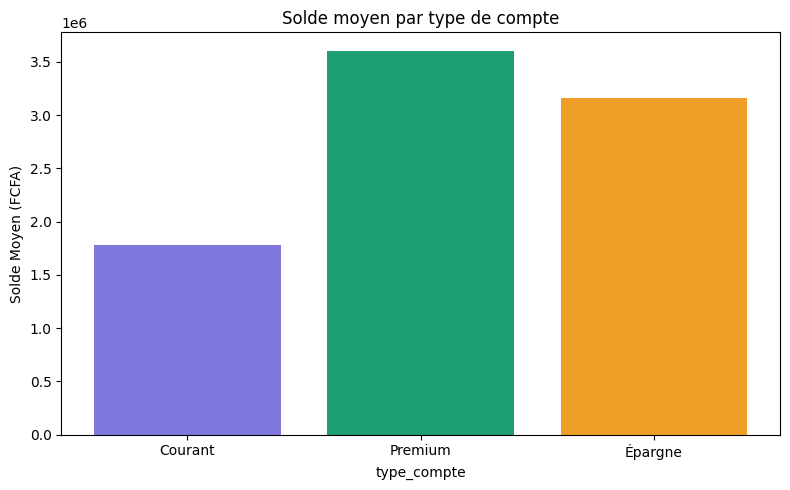

In [58]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Table 1 : Clients
clients = pd.DataFrame({
    "client_id": range(1, 11),
    "nom": ["  alice DUPONT  ", "BOB martin", "Carol SMITH", 
            "david ngono", "EVE BIYA", "frank ESSO",
            "grace MBARGA", "henri TABE", "iris FONING", "jean KOUAM"],
    "ville": ["Douala", "Yaoundé", "Bafoussam", "Douala", "Garoua",
              "Yaoundé", "Douala", "Bafoussam", "Yaoundé", "Douala"],
    "age": [28, 35, 24, 42, 31, 45, 29, 38, 33, 27]
})

# Table 2 : Comptes
comptes = pd.DataFrame({
    "compte_id": range(101, 111),
    "client_id": range(1, 11),
    "type_compte": np.random.choice(["Épargne", "Courant", "Premium"], 10),
    "solde": np.random.randint(10000, 5000000, 10)
})

# Table 3 : Transactions
transactions = pd.DataFrame({
    "transaction_id": range(1001, 1031),
    "compte_id": np.random.choice(range(101, 111), 30),
    "type": np.random.choice(["Dépôt", "Retrait", "Virement"], 30),
    "montant": np.random.randint(5000, 500000, 30),
    "mois": np.random.choice(["Jan", "Fév", "Mar", "Avr"], 30)
})

#1- Nettoie la colonne nom de la table clients (strip, title, double espaces)
clients["nom"]=clients["nom"].str.strip()
clients["nom"]=clients["nom"].str.title()
clients["nom"]=clients["nom"].str.replace("  ", " ")
display(clients['nom'].head())

#2- Joins les 3 tables en une seule — choisis le bon type de jointure
df_complet = pd.merge(clients, comptes, on="client_id", how="inner")
df_complet = pd.merge(df_complet, transactions, on="compte_id", how="left")
print("=== DATASET COMPLET ===")
print(df_complet.head())
print(df_complet.shape)
print(df_complet.describe())
print(df_complet.info())
print(f"\nColonnes : {df_complet.columns.tolist()}")
print(df_complet.duplicated().sum())#Nombre de doublons
test=df_complet.groupby("ville")['montant'].sum()
display("filtre sur les ville et les montant",test)
#3- Calcule le solde moyen par type de compte
# Plus simple — directement sur la table comptes !
solde_moyen = comptes.groupby("type_compte")["solde"].mean().round(2)
print("Solde moyen par type de compte :\n", solde_moyen)

#4- Trouve le client qui a fait le plus de transactions
cli_trans= df_complet.groupby("nom")['transaction_id'].count()
display("Le client ayant fait plus de transaction est:",cli_trans.idxmax())

# 5- Crée une colonne segment : "Premium" si solde > 2 000 000, "Standard" sinon
def classifier_segment(solde):
    if solde > 2000000:
        return "Premium"
    else:
        return "Standard"

# Application
df_complet["segment"] = df_complet["solde"].apply(classifier_segment)

# Affichage
print(df_complet[["nom", "segment"]].head())

# Vérification des statistiques
print(df_complet["segment"].value_counts())

#6- Fais une pivot table : montant moyen des transactions par ville et par mois
pivot = df_complet.pivot_table(
    values="montant",
    index="ville",
    columns="mois",
    aggfunc="mean",
    margins=True,       # ajoute les totaux
    margins_name="Total",
    fill_value=0
).round(0)

print("=== MONTANT MOYEN PAR VILLE ET MOIS ===")
display(pivot)

#7- Trace un graphique du solde moyen par type de compte
solde_type_compte = df_complet.groupby("type_compte")["solde"].mean()

plt.figure(figsize=(8, 5))
plt.bar(solde_type_compte.index, solde_type_compte.values, color=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
plt.title("Solde moyen par type de compte")
plt.xlabel("type_compte")
plt.ylabel("Solde Moyen (FCFA)")
plt.tight_layout()
plt.show()

**💡 Leçon importante : toujours réfléchir à quelle table utiliser pour chaque calcul. Le solde appartient à la table comptes — pas besoin de passer par le dataset complet ! C'est le genre d'erreur qui produit des résultats faux sans message d'erreur**

In [63]:
test=df_complet.groupby("ville")['montant'].sum()
print('filtre sur les ville et les montant',test[['ville'],['montant']])

KeyError: 'key of type tuple not found and not a MultiIndex'

En regardant ta pivot table, quelle ville a le montant moyen de transactions le plus élevé ? Et est-ce cohérent avec ce qu'on sait des données ?<br>
Mais en réalité les deux résultats sont cohérents — ils mesurent des choses différentes <br>
Pour la mesure montant total,le resultat se present comme ceci Douala > Yaoundé > Garoua  -->Douala fait plus de transactions en volume<br>
Pour la mesure Montant moyen par transaction,le resultat se presente comme ceci Garoua > Yaoundé > Douala  -->Chaque transaction à Garoua est plus grosse<br>

#### Exemple concret :

Douala : 10 transactions de 100 000 FCFA → total = 1 000 000 FCFA <br>
Garoua : 2 transactions de 400 000 FCFA → total = 800 000 FCFA<br>
Douala gagne en volume mais Garoua gagne en valeur moyenne par transaction !<br>

### Ce que ça dit sur ta banque :
Les clients de Douala font beaucoup de petites transactions — comportement de transactions courantes<br>
Les clients de Garoua font peu de transactions mais de gros montants — comportement d'épargne ou de virements importants<br>

*# C'est exactement le genre d'insight business qu'un data scientist doit savoir expliquer à sa direction ! 💪 #*